# 0. 프로젝트 시나리오 확인

*  헬스케어 스타트업의 AI 엔지니어로서 다음 미션을 수행해야 함:  
유저가 모바일 애플리케이션으로 업로드한 **경구약 사진을 통해 해당 약에 대한 정보를 확인할 수 있는 이미지 인식 모델**을 구축하기!

*  기업에서는 이를 통해 **유저의 건강 상태 및 함께 복용하면 안되는 약 등 헬스케어 정보**를 유저들에게 제공함으로써 비즈니스적인 가치를 만들어낼 수 있음.

# 1. 데이터 파악

| 구분 | 타입 | 필수여부 | 설명 |
| :--- | :--- | :---: | :--- |
| images | Object | M | 약제 이미지정보 |
| images[].id | Number | M | 약제 이미지식별자 |
| images[].width | Number | M | 약제 이미지너비 |
| images[].height | Number | M | 약제 이미지높이 |
| images[].file_name | String | M | 약제 이미지파일명 |
| images[].drug_N | String | M | 알약코드 |
| images[].drug_S | String | M | 알약상태 |
| images[].back_color | String | M | 촬영배경 |
| images[].drug_dir | String | M | 알약방향 |
| images[].light_color | String | M | 촬영조명 |
| images[].camera_la | Number | M | 카메라위도 |
| images[].camera_lo | Number | M | 카메라경도 |
| images[].size | Number | M | 이미지 사이즈 |
| images[].dl_idx | String | M | 알약 식별자 |
| images[].dl_mapping_code | String | M | 제품코드 |
| images[].dl_name | String | M | 제품명 |
| images[].dl_name_en | String | O | 제품명(영어) |
| images[].img_key | String | M | 이미지 링크 |
| images[].dl_material | String | M | 성분명 |
| images[].dl_material_en | String | O | 성분명(영어) |
| images[].dl_custom_shape | String | M | 제조 모양 |
| images[].dl_company | String | M | 제조사명 |
| images[].dl_company_en | String | O | 제조사명(영어) |
| images[].di_company_mf | String | M | 위탁제조사명 |
| images[].di_company_mf_en | String | O | 위탁제조사명(영어) |
| images[].item_seq | Number | M | 품목기준코드 |
| images[].di_item_permit_date | Date | O | 허가일자 |
| images[].di_class_no | String | M | 약품 분류 |
| images[].di_etc_otc_code | String | M | 전문의약품/일반의약품 |
| images[].di_edi_code | String | M | EDI 코드 |
| images[].chart | String | M | 알약 제형 |
| images[].drug_shape | String | M | 알약 모양 |
| images[].thick | Number | M | 알약 두께 |
| images[].leng_long | Number | M | 알약 장축 |
| images[].leng_short | Number | M | 알약 단축 |
| images[].print_front | String | C | 식별문자_앞 |
| images[].print_back | String | C | 식별문자_뒤 |
| images[].color_class1 | String | M | 색상 1 |
| images[].color_class2 | String | O | 색상 2 |
| images[].line_front | String | M | 알약 앞면분할선 여부 |
| images[].line_back | String | M | 알약 뒷면분할선 여부 |
| images[].img_regist_ts | Date | O | 약학정보원 이미지 생성일 |
| images[].form_code_name | String | M | 정제 분류명 |
| images[].mark_code_front_anal | String | M | 알약 앞면마크 형태 |
| images[].mark_code_back_anal | String | M | 알약 뒷면마크 형태 |
| images[].mark_code_front_img | String | M | 알약 앞면마크 이미지 |
| images[].mark_code_back_img | String | M | 알약 뒷면마크 이미지 |
| images[].mark_code_front | String | M | 알약 앞면마크 코드 |
| images[].mark_code_back | String | M | 알약 뒷면마크 코드 |
| images[].change_date | Date | O | 변경일자 |
| type | type | O | json 타입 |
| annotations | Object | M | 라벨링정보 |
| annotations[].area | Number | M | 바운딩박스 면적 |
| annotations[].iscrowd | Number | O | 평가 분류 |
| annotations[].bbox | List | M | bbox 좌표 |
| annotations[].category_id | Number | M | category 아이디 |
| annotations[].ignore | Number | O | 무시 여부 |
| annotations[].segmentation | List | O | 라벨링바운딩 박스 |
| annotations[].image_id | Number | M | 이미지 아이디 |
| annotations[].id | Number | M | 어노테이션 아이디 |
| categories | Object | M | 라이선스 |
| categories[].supercategory | String | M | 슈퍼 카테고리 |
| categories[].id | Number | M | 카테고리 아이디 |
| categories[].name | String | C | 카테고리 명 |

# 2. 데이터 전처리

### 2-1. 데이터 불러오기

In [1]:
import os

# 인증 설정
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/content/kaggle.json')
os.chmod('/content/kaggle.json', 600)

# 데이터 저장 폴더 생성
os.makedirs('/content/data', exist_ok=True)

# 데이터셋 다운로드
!kaggle competitions download -c ai09-level1-project -p /content/data

# 압축 해제
!unzip /content/data/ai09-level1-project.zip -d /content/data/

ai09-level1-project.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  /content/data/ai09-level1-project.zip
replace /content/data/sprint_ai_project1_data/test_images/1.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: ㅜ
error:  invalid response [ㅜ]
replace /content/data/sprint_ai_project1_data/test_images/1.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace /content/data/sprint_ai_project1_data/test_images/10.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [2]:
import torch

# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [3]:
import os
import glob

# 경로 설정
base_dir = '/content/data/sprint_ai_project1_data'

train_img_dir = os.path.join(base_dir, 'train_images')       # 학습 이미지
train_json_dir = os.path.join(base_dir, 'train_annotations') # 학습 annotation
test_img_dir = os.path.join(base_dir, 'test_images')         # 테스트 이미지

# 파일 목록 가져오기
train_img_files = glob.glob(os.path.join(train_img_dir, "*.png"))
test_img_files = glob.glob(os.path.join(test_img_dir, "*.png"))
train_json_files = glob.glob(os.path.join(train_json_dir, "**/*.json"), recursive=True)

print(f"학습 이미지 수: {len(train_img_files)}")
print(f"테스트 이미지 수: {len(test_img_files)}")
print(f"Annotation 수: {len(train_json_files)}")

학습 이미지 수: 232
테스트 이미지 수: 842
Annotation 수: 763


In [4]:
### 이미지 경로 + 약 정보 + json 파일을 한꺼번에 보는 데이터프레임 생성 ###

import os
import json
import glob
import pandas as pd
from pathlib import Path

records = []

for json_path in glob.glob(os.path.join(train_json_dir, '**/*.json'), recursive=True):
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    # --- 각 섹션 파싱 ---
    images      = {img['id']: img  for img  in data.get('images',      [])}
    annotations = data.get('annotations', [])
    categories  = {cat['id']: cat['name'] for cat in data.get('categories', [])}

    for ann in annotations:
        img_id   = ann['image_id']
        img_info = images.get(img_id, {})
        cat_id   = ann['category_id']

        records.append({
            # 이미지 정보
            'image_name'    : img_info.get('file_name'),
            'width'         : img_info.get('width'),
            'height'        : img_info.get('height'),

            # 약 식별 정보
            'drug_N'        : img_info.get('drug_N'),
            'dl_name'       : img_info.get('dl_name'),        # 약 이름 (한글)
            'dl_name_en'    : img_info.get('dl_name_en'),     # 약 이름 (영문)
            'dl_company'    : img_info.get('dl_company'),     # 제조사

            # 약 외형 정보 (이미지 인식에 유용)
            'drug_shape'    : img_info.get('drug_shape'),     # 모양 (타원형 등)
            'color_class1'  : img_info.get('color_class1'),   # 색상
            'print_front'   : img_info.get('print_front'),    # 앞면 각인
            'print_back'    : img_info.get('print_back'),     # 뒷면 각인
            'drug_dir'      : img_info.get('drug_dir'),       # 앞면/뒷면
            'form_code_name': img_info.get('form_code_name'), # 제형 (필름코팅정 등)

            # 촬영 조건
            'camera_la'     : img_info.get('camera_la'),      # 카메라 각도
            'back_color'    : img_info.get('back_color'),     # 배경색
            'light_color'   : img_info.get('light_color'),    # 조명색

            # Annotation 정보
            'bbox'          : ann.get('bbox'),                 # [x, y, w, h]
            'area'          : ann.get('area'),
            'category_id'   : cat_id,
            'label'         : categories.get(cat_id),         # 약 이름 (라벨)

            # 경로
            'json_path'     : json_path,
        })

df = pd.DataFrame(records)

# 이미지 전체 경로 추가
df['img_path'] = df['image_name'].apply(
    lambda x: os.path.join(train_img_dir, x) if pd.notna(x) else None
)

# 라벨 인코딩
df['label_id'] = pd.factorize(df['label'])[0]

print(f"전체 레코드 수 : {len(df)}")
print(f"클래스 수      : {df['label_id'].nunique()}")
print(f"컬럼 목록      : {df.columns.tolist()}")
df.head(3)

전체 레코드 수 : 763
클래스 수      : 56
컬럼 목록      : ['image_name', 'width', 'height', 'drug_N', 'dl_name', 'dl_name_en', 'dl_company', 'drug_shape', 'color_class1', 'print_front', 'print_back', 'drug_dir', 'form_code_name', 'camera_la', 'back_color', 'light_color', 'bbox', 'area', 'category_id', 'label', 'json_path', 'img_path', 'label_id']


,image_name,width,height,drug_N,dl_name,dl_name_en,dl_company,drug_shape,color_class1,print_front,...,camera_la,back_color,light_color,bbox,area,category_id,label,json_path,img_path,label_id
0,K-003351-033880-035206_0_2_0_2_90_000_200.png,976,1280,K-035206,아토젯정 10/40mg,Atozet Tab. 10/40mg,한국엠에스디(주),타원형,하양,337,...,90,연회색 배경,주백색,"[502, 848, 428, 203]",86884,35206,아토젯정 10/40mg,/content/data/sprint_ai_project1_data/train_an...,/content/data/sprint_ai_project1_data/train_im...,0
1,K-003351-033880-035206_0_2_0_2_75_000_200.png,976,1280,K-035206,아토젯정 10/40mg,Atozet Tab. 10/40mg,한국엠에스디(주),타원형,하양,337,...,75,연회색 배경,주백색,"[457, 748, 434, 217]",94178,35206,아토젯정 10/40mg,/content/data/sprint_ai_project1_data/train_an...,/content/data/sprint_ai_project1_data/train_im...,0
2,K-003351-033880-035206_0_2_0_2_90_000_200.png,976,1280,K-033880,글리틴정(콜린알포세레이트),Glitin Tab.,제일약품(주),타원형,주황,,...,90,연회색 배경,주백색,"[78, 762, 441, 283]",124803,33880,글리틴정(콜린알포세레이트),/content/data/sprint_ai_project1_data/train_an...,/content/data/sprint_ai_project1_data/train_im...,1


In [5]:
### 이미지~annotation 불일치 확인 ###
actual_imgs = set(Path(p).name for p in glob.glob(os.path.join(train_img_dir, '*.png')))
df_imgs     = set(df['image_name'].dropna())

no_annotation = actual_imgs - df_imgs
no_image      = df_imgs - actual_imgs

print(f"실제 이미지 수          : {len(actual_imgs)}")
print(f"annotation 기록 이미지  : {len(df_imgs)}")
print(f"annotation 없는 이미지  : {len(no_annotation)}개")
print(f"이미지 없는 annotation  : {len(no_image)}개")

실제 이미지 수          : 232
annotation 기록 이미지  : 232
annotation 없는 이미지  : 0개
이미지 없는 annotation  : 0개


In [6]:
# 이미지 파일이 실제로 존재하는 행만 유지
df_clean = df[df['image_name'].isin(actual_imgs)].reset_index(drop=True)
print(f"학습 사용 데이터: {len(df_clean)}행 / {df_clean['label_id'].nunique()}클래스")

from torch.utils.data import Dataset
from PIL import Image

class MedicineDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row['img_path']).convert('RGB')
        label = row['label_id']

        if self.transform:
            image = self.transform(image)

        return image, label

학습 사용 데이터: 763행 / 56클래스


In [6]:
### 약 표면 음각 문자 식별에 가장 적합한 CLAHE 대비 보정법 이용 ###
import os
import glob
import cv2
import numpy as np
from pathlib import Path

# CLAHE 적용 이미지를 저장할 출력 폴더
train_out_dir = os.path.join(base_dir, 'train_images_clahe')
test_out_dir  = os.path.join(base_dir, 'test_images_clahe')

os.makedirs(train_out_dir, exist_ok=True)
os.makedirs(test_out_dir,  exist_ok=True)

# ── CLAHE 설정 ───────────────────────────────────────────────
# clipLimit  : 대비 증폭 상한 (높을수록 강한 보정, 노이즈 증가 위험)
# tileGridSize: 이미지를 나누는 격자 크기 (작을수록 지역적 보정 강화)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

# ── 핵심 함수 ────────────────────────────────────────────────
def apply_clahe(img_path: str, out_dir: str) -> np.ndarray:
    """
    단일 이미지에 CLAHE를 적용하고 저장합니다.
    - 컬러 이미지: LAB 색공간의 L(밝기) 채널에만 적용 → 색상 왜곡 없음
    - 그레이스케일: 직접 적용
    """
    img = cv2.imread(img_path)
    if img is None:
        print(f"[WARN] 읽기 실패: {img_path}")
        return None

    if len(img.shape) == 3:                        # 컬러 이미지
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        l_clahe = clahe.apply(l)                   # L 채널에만 적용
        lab_clahe = cv2.merge([l_clahe, a, b])
        result = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)
    else:                                          # 그레이스케일
        result = clahe.apply(img)

    out_path = os.path.join(out_dir, Path(img_path).name)
    cv2.imwrite(out_path, result)
    return result

# ── Train / Test 일괄 처리 ───────────────────────────────────
def process_dataset(img_dir: str, out_dir: str, label: str):
    files = glob.glob(os.path.join(img_dir, "*.png"))
    print(f"\n[{label}] 총 {len(files)}장 처리 시작")

    ok, fail = 0, 0
    for path in files:
        result = apply_clahe(path, out_dir)
        if result is not None:
            ok += 1
        else:
            fail += 1

    print(f"[{label}] 완료 → 성공: {ok}, 실패: {fail}")
    print(f"[{label}] 저장 경로: {out_dir}")

process_dataset(train_img_dir, train_out_dir, "TRAIN")
process_dataset(test_img_dir,  test_out_dir,  "TEST")


[TRAIN] 총 232장 처리 시작
[TRAIN] 완료 → 성공: 232, 실패: 0
[TRAIN] 저장 경로: /content/data/sprint_ai_project1_data/train_images_clahe

[TEST] 총 842장 처리 시작
[TEST] 완료 → 성공: 842, 실패: 0
[TEST] 저장 경로: /content/data/sprint_ai_project1_data/test_images_clahe


/tmp/ipykernel_17468/3268769138.py:39: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17468/3268769138.py:39: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


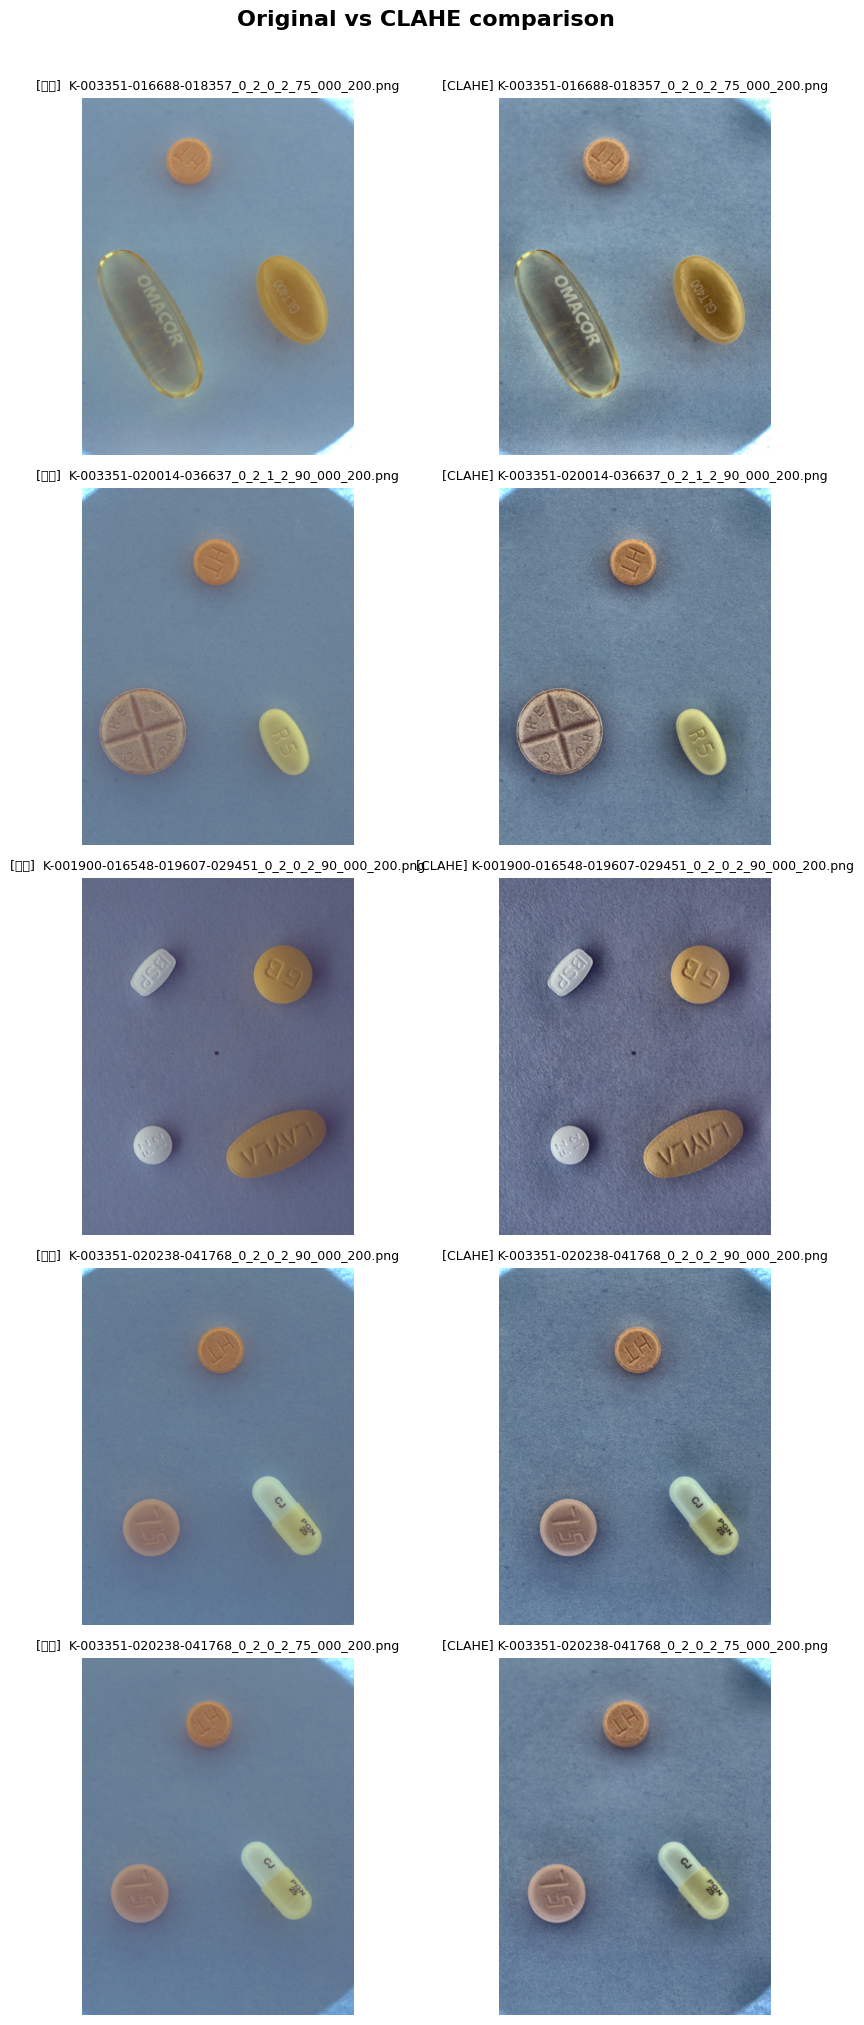

In [8]:
### 원본 vs CLAHE 보정 이미지를 랜덤하게 뽑아 나란히 비교 시각화 ###

import random
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def visualize_clahe_comparison(
    original_dir: str,
    clahe_dir: str,
    n_samples: int = 5,
    seed: int = 42
):
    """
    원본 vs CLAHE 보정 이미지를 나란히 비교 시각화합니다.
    """
    random.seed(seed)
    files = glob.glob(os.path.join(original_dir, "*.png"))
    samples = random.sample(files, min(n_samples, len(files)))

    fig, axes = plt.subplots(n_samples, 2, figsize=(10, 4 * n_samples))
    fig.suptitle("Original vs CLAHE comparison", fontsize=16, fontweight='bold', y=1.01)

    for i, orig_path in enumerate(samples):
        fname = Path(orig_path).name
        clahe_path = os.path.join(clahe_dir, fname)

        # 이미지 로드 (BGR → RGB)
        orig_img  = cv2.cvtColor(cv2.imread(orig_path),  cv2.COLOR_BGR2RGB)
        clahe_img = cv2.cvtColor(cv2.imread(clahe_path), cv2.COLOR_BGR2RGB)

        axes[i, 0].imshow(orig_img)
        axes[i, 0].set_title(f"[원본]  {fname}", fontsize=9)
        axes[i, 0].axis('off')

        axes[i, 1].imshow(clahe_img)
        axes[i, 1].set_title(f"[CLAHE] {fname}", fontsize=9)
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()


# 실행
visualize_clahe_comparison(
    original_dir=train_img_dir,
    clahe_dir=train_out_dir,
    n_samples=5,       # 확인할 이미지 수
    seed=42            # 재현성을 위한 시드 고정
)

In [9]:
### K-Fold Cross Validation ###
# 232장에서 Validation까지 떼면 학습 데이터가 너무 적어짐

from sklearn.model_selection import StratifiedKFold

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# → 매 fold마다 Train 185장 / Val 47장으로 순환
# → 5번 학습해서 평균 성능으로 모델 평가

In [10]:
### 데이터 증강 Trasnform 정의 ###
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((384, 384)),

    # 기하학적 변환
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=15),

    # 약 이미지 특화 — 밝기/대비 변화 대응
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.1),
    transforms.RandomGrayscale(p=0.1),

    # 미세 텍스트 손상 방지를 위해 블러는 약하게
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5)),

    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# 테스트셋 — Resize와 Normalize만 적용
test_transform = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])